## Imports

In [1]:
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [ ]:
import networkx as nx
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from ligo.skymap import plot  # noqa: F401
from m4opt.fov import contains
from m4opt.milp import Model
from m4opt.skygrid import _geodesic
from m4opt.utils.console import progress, status
from m4opt.utils.optimization import partition_graph_color
from matplotlib import pyplot as plt
from regions import PointSkyRegion, Regions

## Basic parameters

* `geodesic_args`: Parameters of the geodesic sky grid tiling.
* `k`: Number of sky blocks.

In [3]:
# Valutes for actual survey
# geodesic_args = (21, 4, "icosahedron")
# k = 240

# Values for fast test of algorithm
geodesic_args = (2, 2, "icosahedron")
k = 5

## Problem setup

Generate sky grid.

In [4]:
coords = _geodesic.for_subdivision(*geodesic_args)

Generate costs: proportional to the number of exposures required for each field.

FIXME: Currently we are computing weights for each field based on whether their _center_ is within a given region. We should compute weights based on whether they _overlap_ a given region.

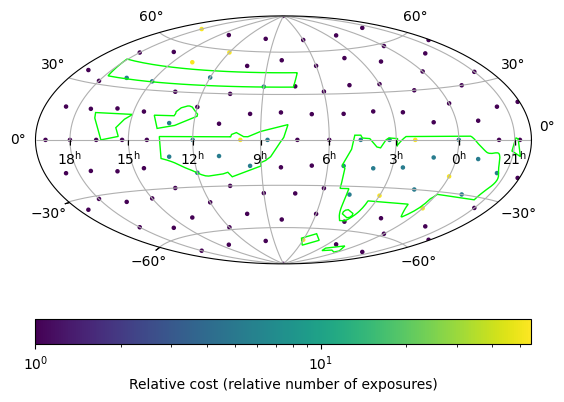

In [5]:
# Exposure times and candeces taken from UVEX Design Reference Mission
# Version 1.0, 11/20/2025
base_limmag = np.asarray([25.25, 24.25])  # All-sky (NUV, MUV) survey depth
base_limmag += 1.25 * np.log10(3)  # 3 exposures per year, cadence of 1/(4 months)

lmlz_wide_limmag = np.asarray([25.75, 25.75])
lmlz_deep_limmag = np.asarray([27.0, 27.0])
mc_limmag = np.asarray([24.5, 24.5])  # Magellanic clouds survey depth
mc_limmag += 1.25 * np.log10(52 * 2)  # 2/week cadence

lmlz_wide_regions = Regions.read("survey-footprints/lmlz-wide.ds9")

# Split apart LMLZ regions from point-like targets
lmlz_deep_regions = Regions.read("survey-footprints/lmlz-deep.ds9")
lmlz_deep_points = SkyCoord(
    [
        region.center
        for region in lmlz_deep_regions
        if isinstance(region, PointSkyRegion)
    ]
)
lmlz_deep_regions = Regions(
    [region for region in lmlz_deep_regions if not isinstance(region, PointSkyRegion)]
)
near_lmlz_deep_points = np.zeros(len(coords), dtype=bool)
near_lmlz_deep_points[
    lmlz_deep_points.match_to_catalog_sky(coords).indices_to_catalog
] = True

mc_regions = Regions.read("survey-footprints/magellanic-clouds.ds9")

costs = np.max(
    [
        # Base survey
        np.full(len(coords), 1),
        np.where(
            contains(lmlz_wide_regions, coords),
            10 ** ((lmlz_wide_limmag - base_limmag).max() / 1.25),
            1,
        ),
        np.where(
            contains(lmlz_deep_regions, coords) | near_lmlz_deep_points,
            10 ** ((lmlz_deep_limmag - base_limmag).max() / 1.25),
            1,
        ),
        np.where(
            contains(mc_regions, coords),
            10 ** ((mc_limmag - base_limmag).max() / 1.25),
            1,
        ),
    ],
    axis=0,
)

ax = plt.axes(projection="astro aitoff", center="8h 0d")
plt.colorbar(
    ax.scatter(
        coords.ra.deg,
        coords.dec.deg,
        s=5,
        c=costs,
        transform=ax.get_transform("world"),
        cmap="viridis",
        norm="log",
    ),
    orientation="horizontal",
).set_label("Relative cost (relative number of exposures)")
for region in [*lmlz_wide_regions, *lmlz_deep_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist())
ax.grid()

Convert to a weighted graph.

In [6]:
# Construct graph from nearest neighbors
distances = coords[:, np.newaxis].separation(coords).to_value(u.deg)
np.fill_diagonal(distances, np.inf)  # no loops
n = 2 * _geodesic.num_edges(*geodesic_args)
i = np.argpartition(distances, n, axis=None)[:n]
adjacency = np.zeros_like(distances, dtype=bool)
adjacency.flat[i] = True
graph = nx.from_numpy_array(adjacency)

# Add costs to graph
for (_, data), cost in zip(graph.nodes(data=True), costs):
    data["cost"] = cost

## Partition into sky blocks

We have $N$ fields. Our objective is to partition them into $k$ connected blocks, such that all blocks contain between $n_\mathrm{min} = \left\lfloor\frac{N}{k}\right\rfloor$ and $n_\mathrm{max} = \left\lceil\frac{N}{k}\right\rceil$ fields. Each field has an associated weight which is proportional to the number of exposures required. The weight of each block is the maximum of the weights of all of the fields inside it. We want to minimize the sum of the weights of all of the blocks.

This is a variation of the Balanced Connected Partition (BCP) problem. We use an adaptation of the MILP formulation given in Section 4 of [arXiv:1911.05723](https://arxiv.org/abs/1911.05723). Consider a graph $G$ with vertex set $V(G)$ and edge set $E(G)$. Let $w : V(G) \rightarrow \mathbb{R}$ be a function that assigns weights to each vertex of $G$. Let $w_\mathrm{min} = \min_{v \in V(G)} {w(v)}$, $w_\mathrm{max} = \max_{v \in V(G)} {w(v)}$. Create a digraph $D_G \subset D$ with arc set $A(D)$ as in [arXiv:1911.05723](https://arxiv.org/abs/1911.05723): for each edge in $G$, create two arcs with the same nodes but in both opposite directions. Then add $k$ new vertices from the set $S = \left\{ s_1, \dots, s_k \right\}$. Finally, add an arc from each vertex in $S$ to each vertex in $G$, the subgraph containing only those arcs forming graph $D_S \subset D$. Denote the set of arcs going into node $v$ by $\delta^-(v)$ and the set of arcs going out of the node by $\delta^+(v)$.

Bounded integer variables representing the flows between nodes $V(G)$:

$$
    f_a \in \mathbb{Z} \mid 0 \leq f_a \leq n_\mathrm{max} - 1 \quad \forall a \in A(D_G)
$$

Semiinteger variables representing the flows between $S$ and $V(G)$:

$$
    f_a \in \mathbb{Z} \mid f_a = 0 \lor n_\mathrm{min} \leq f_a \leq n_\mathrm{max} \quad \forall a \in A(D_G)
$$

Bounded real variables representing the cost of the flow emanating from each node:

$$
    x_v \in \mathbb{R} \mid w(v) \leq x_v \leq w_\mathrm{max} \quad \forall v \in V(D)
$$

Each node consumes exactly 1 unit of flow.

$$
    \sum_{a \in \delta^-(v)} f_a - \sum_{a \in \delta^+(v)} f_a = 1 \quad \forall V(D) \setminus S
$$

SOS1 constraints enforcing that exactly one arc from each node $s$ in $S$ has nonzero flow:

$$
    \mathrm{SOS1}(\left\{f_a | a \in \delta^+(s)\right\}) \quad \forall s \in S
$$

SOS1 constraints enforcing that, for each node $v$ in $V(G)$, exactly one inbound arc has nonzero flow:

$$
    \mathrm{SOS1}(\left\{f_a | a \in \delta^-(s)\right\}) \quad \forall v \in V(D) \setminus S
$$

If-then constraints enforcing that, for each arc in the graph, if there is nonzero flow across the arc, then the cost of the source node is greater than or equal to the cost of the sink node.

$$
    f_a \geq 1 \Rightarrow x_u \geq x_v \quad \forall a = (u, v) \in A(D)
$$

Minimize the quantity

$$
    \sum_{s \in S} x_s
$$

In [7]:
nmin = int(np.floor(graph.number_of_nodes() / k))
nmax = int(np.ceil(graph.number_of_nodes() / k))
min_cost = min(data["cost"] for _, data in graph.nodes(data=True))
max_cost = max(data["cost"] for _, data in graph.nodes(data=True))

with progress():
    with status("augmenting graph"):
        # Construct digraph with edges only from nodes only in the direction of nondecreasing cost
        digraph = graph.to_directed()

        # Add nodes for flow sources for each subgraph
        unique = object()
        flow_source_nodes = [(unique, i) for i in range(k)]

        # Add edges from each flow source to each node
        digraph.add_nodes_from(flow_source_nodes, cost=min_cost)
        digraph.add_weighted_edges_from(
            (
                (node1, node2, data["cost"])
                for node1 in flow_source_nodes
                for node2, data in graph.nodes(data=True)
            ),
            weight="cost",
        )

    with Model(timelimit=2 * u.minute) as m:
        with status("adding flow variables"):
            for node1, node2, data in digraph.edges(data=True):
                if node1 in flow_source_nodes:
                    data["flow"] = m.semiinteger_var(lb=nmin, ub=nmax)
                else:
                    data["flow"] = m.integer_var(lb=0, ub=nmax - 1)

        with status("adding cost variables"):
            for _, data in digraph.nodes(data=True):
                data["cost"] = m.continuous_var(lb=data["cost"], ub=max_cost)

        with status("adding constraint: each node consumes exactly 1 unit of flow"):
            m.add_constraints_(
                m.sum_vars_all_different(
                    data["flow"] for _, _, data in digraph.in_edges(node, data=True)
                )
                - m.sum_vars_all_different(
                    data["flow"] for _, _, data in digraph.out_edges(node, data=True)
                )
                == 1
                for node in graph.nodes
            )

        with status("adding constraint: uniqueness of out flows"):
            # Each flow source node sends flow to exactly one other node
            for node in flow_source_nodes:
                m.add_sos1(
                    [data["flow"] for _, _, data in digraph.out_edges(node, data=True)]
                )

        with status("adding constraint: uniqueness of in flows"):
            # Each node consumes flow from exactly one other node
            for node in graph.nodes:
                m.add_sos1(
                    [data["flow"] for _, _, data in digraph.in_edges(node, data=True)]
                )

        with status("adding constraint: costs"):
            node_costs = digraph.nodes(data="cost")
            for node1, node2, edge_data in digraph.edges(data=True):
                m.add_if_then(
                    edge_data["flow"] >= 1, node_costs[node1] >= node_costs[node2]
                )

        with status("adding objective"):
            m.minimize(
                m.sum_vars_all_different(
                    [
                        data["cost"]
                        for node, data in digraph.nodes(data=True)
                        if node in flow_source_nodes
                    ]
                )
            )

        with status("solving"):
            solution = m.solve()

    with status("reading solution"):
        edges, flows = list(
            zip(
                *(((v1, v2), data["flow"]) for v1, v2, data in digraph.edges(data=True))
            )
        )
        flows = np.rint(solution.get_values(flows)).astype(bool)
        digraph.remove_edges_from(edge for edge, flow in zip(edges, flows) if not flow)
        digraph.remove_nodes_from(flow_source_nodes)
        out_graph = nx.convert_node_labels_to_integers(
            digraph.to_undirected(as_view=True)
        )
        partition = np.empty(out_graph.number_of_nodes(), dtype=np.intp)
        for component, nodes in enumerate(nx.connected_components(out_graph)):
            partition[list(nodes)] = component

partition

Version identifier: 22.1.2.0 | 2024-12-02 | 8bd2200c8
CPXPARAM_Read_DataCheck                          1
CPXPARAM_Parallel                                -1
CPXPARAM_Emphasis_MIP                            1
CPXPARAM_MIP_Pool_Capacity                       0
CPXPARAM_TimeLimit                               120
CPXPARAM_WorkDir                                 "/var/folders/w5/pgrtm0vs1psb88v7z4fz0lh084mbdz/T"
Tried aggregator 2 times.
MIP Presolve eliminated 1046 rows and 7 columns.
MIP Presolve added 2092 rows and 523 columns.
MIP Presolve modified 354 coefficients.
Aggregator did 365 substitutions.
Reduced MIP has 5995 rows, 4872 columns, and 23299 nonzeros.
Reduced MIP has 2457 binaries, 1330 generals, 0 SOSs, and 2603 indicators.
Presolve time = 0.01 sec. (14.15 ticks)
Probing time = 0.01 sec. (15.86 ticks)
Tried aggregator 2 times.
Detecting symmetries...
Aggregator did 2 substitutions.
Reduced MIP has 5993 rows, 4870 columns, and 23297 nonzeros.
Reduced MIP has 2457 binaries, 1330

array([0, 1, 2, 3, 1, 4, 0, 3, 2, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 4, 0, 1,
       4, 4, 4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1,
       1, 2, 2, 2, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
       3, 3, 3, 3, 2, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 0, 0, 3, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 4, 4, 0,
       4, 4, 4, 4, 2, 4, 2, 3, 4, 4, 4, 4])

/Users/lpsinger/src/uvex-scheduler/.venv/lib/python3.13/site-packages/regions/shapes/polygon.py:180: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Polygon(xy=xy, **mpl_kwargs)


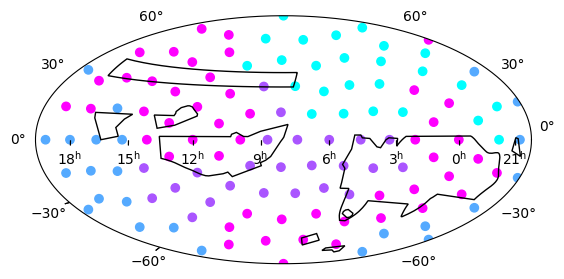

In [8]:
ax = plt.axes(projection="astro aitoff", center="8h 0d")
ax.scatter(
    coords.ra.deg,
    coords.dec.deg,
    c=partition_graph_color(graph, partition)[partition],
    cmap="cool",
    transform=ax.get_transform("world"),
)
for region in [*lmlz_wide_regions, *lmlz_deep_regions, *mc_regions]:
    ax.add_patch(region.to_pixel(ax.wcs).as_artist(color="black"))